# 12. Interpolation

Moving values between point clouds and rasters with `sylva.interpolate`:
labels computed on a thinned copy carried back to every point, terrain
models interpolated from the ground returns, and rasters read back onto the
points as attributes. The [guide](../guide/interpolation.md) describes the
methods.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set
import pandas as pd
from sylva import filters, ground, interpolate, trees

cloud = sylva.read(DATA / "litch_tile.laz")

## Labels from a thinned copy

Much of the work on a plot cloud is done on a thinned copy, and the result
then has to reach every point. The tile's own `classification` (ground and
vegetation, from PMF) is known at every point, so it shows how well a
transfer does: thin to 20 cm, carry the classes back, and compare.
`"nearest"` copies the class of the nearest point of the copy;
`"majority"` takes the most common class of the `k` nearest, which is the
method for labels, since they must not be averaged.

In [2]:
thin = filters.voxel_downsample(cloud, 0.2)
truth = cloud.attrs["classification"]
print(f"{len(thin):,} points in the 20 cm copy, {len(cloud):,} in the tile")
for method, k in (("nearest", 1), ("majority", 5), ("majority", 9)):
    back = interpolate.transfer_attributes(thin, cloud, "classification", method=method, k=k)
    agree = back.attrs["classification"] == truth
    print(f"{method:8s} k = {k}: {agree.mean():.2%} of the points get their own class back")
back = interpolate.transfer_attributes(thin, cloud, "classification", method="majority", k=5)
wrong = back.attrs["classification"] != truth
print(f"of the points that do not, {np.mean(cloud.z[wrong] < 1.0):.0%} lie below 1 m")

92,061 points in the 20 cm copy, 1,553,677 in the tile
nearest  k = 1: 97.79% of the points get their own class back


majority k = 5: 97.66% of the points get their own class back


majority k = 9: 97.49% of the points get their own class back
of the points that do not, 100% lie below 1 m


The labels that do not come back lie where ground and grass meet,
which a 20 cm copy cannot resolve. On this tile the majority vote does no
better than the nearest point: the classes form large, clean regions, and
the vote only helps where isolated labels are wrong.

The same holds for trees. Segmentation (notebook 5) is one of the costlier
steps and grows with the number of points, so a common pattern is to
segment a 10 cm copy and carry `tree_id` back. Here both run from the same
stems, and the segmentation of the full tile is the reference.
`max_distance` leaves a point with no labelled point within 15 cm
unassigned (-1) rather than copying a distant label.

In [3]:
import time

cloud = ground.normalize_height(cloud, ground.make_dtm(cloud, 0.5, bounds=(0, 0, 20, 20)))
stems, _ = trees.merge_branches(cloud, trees.detect_stems(cloud))
t0 = time.perf_counter()
direct = np.asarray(trees.segment_trees(cloud, stems))
t_full = time.perf_counter() - t0

t0 = time.perf_counter()
coarse = filters.voxel_downsample(cloud, 0.1)
coarse = coarse.with_attrs(tree_id=np.asarray(trees.segment_trees(coarse, stems)))
moved = interpolate.transfer_attributes(coarse, cloud, "tree_id", method="majority", k=5, max_distance=0.15)
t_coarse = time.perf_counter() - t0

tid = moved.attrs["tree_id"]
in_tree = (direct > 0) | (tid > 0)
print(f"segmenting all {len(cloud):,} points: {t_full:.1f} s; "
      f"{len(coarse):,} points and the transfer: {t_coarse:.1f} s")
print(f"the same label as the full segmentation: {np.mean(tid == direct):.1%} of all points, "
      f"{np.mean(tid[in_tree] == direct[in_tree]):.1%} of the points either assigns to a tree")

segmenting all 1,553,677 points: 2.5 s; 402,192 points and the transfer: 0.9 s
the same label as the full segmentation: 98.7% of all points, 97.6% of the points either assigns to a tree


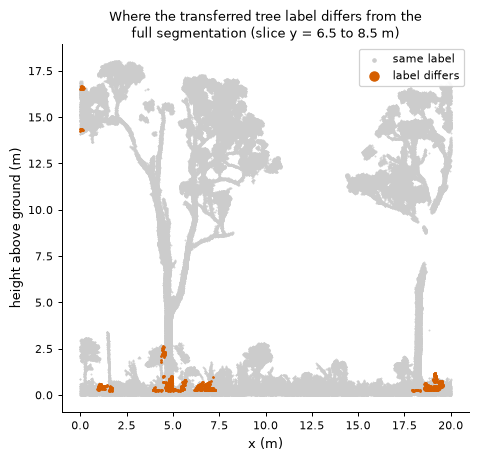

In [4]:
slab = (cloud.y > 6.5) & (cloud.y < 8.5)
differ = slab & in_tree & (tid != direct)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(cloud.x[slab], cloud.attrs["height"][slab], s=0.2, c=CONTEXT, label="same label")
ax.scatter(cloud.x[differ], cloud.attrs["height"][differ], s=1.5, c="C3", label="label differs")
ax.set(title="Where the transferred tree label differs from the\nfull segmentation (slice y = 6.5 to 8.5 m)",
       xlabel="x (m)", ylabel="height above ground (m)", aspect="equal")
ax.legend(markerscale=6, loc="upper right");

## Terrain models by interpolation

`ground.make_dtm` takes the lowest ground point in each cell by default.
With `method="tin"`, `"natural"` or `"idw"` it interpolates the ground
points instead: a linear surface on a Delaunay triangulation, Sibson's
natural-neighbour weights, or inverse-distance weighting. These surfaces
pass through the points, so they follow the ground returns rather than
their lowest members, and they carry the returns' noise unless the ground is
thinned first; here it is thinned to 25 cm.

In [5]:
ground_pts = filters.voxel_downsample(cloud[ground.ground_mask(cloud)], 0.25)
lowest = ground.make_dtm(cloud, 0.25, bounds=(0, 0, 20, 20))
dtms = {m: ground.make_dtm(ground_pts, 0.25, bounds=(0, 0, 20, 20), method=m) for m in ("tin", "natural", "idw")}
rows = []
for m, d in dtms.items():
    diff = d.data - lowest.data
    rows.append({"method": m, "median above lowest (m)": np.nanmedian(diff),
                 "5th percentile": np.nanpercentile(diff, 5), "95th percentile": np.nanpercentile(diff, 95)})
print(f"{len(ground_pts):,} ground points after thinning; grids of {lowest.data.shape[1]} x {lowest.data.shape[0]} cells")
pd.DataFrame(rows).round(3)

9,292 ground points after thinning; grids of 81 x 81 cells


,method,median above lowest (m),5th percentile,95th percentile
0,tin,0.062,0.010,0.120
1,natural,0.062,0.013,0.115
2,idw,0.066,0.018,0.111


`make_dtm` fills the cells outside the ground points' convex hull from
the nearest interpolated cell, so its DTM has no gaps, like the default.
`interpolate.grid` keeps them, and with `max_distance` also leaves out cells
far from any ground point, which keeps the surface from bridging the ground
hidden under stems and shrubs.

cells with no ground point within 0.5 m: 2.5%


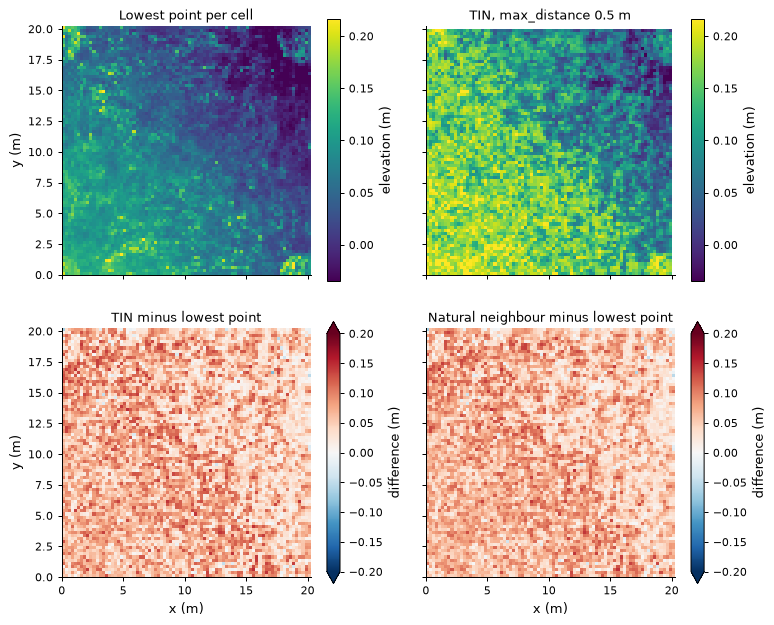

In [6]:
holes = interpolate.grid(ground_pts, 0.25, method="tin", bounds=(0, 0, 20, 20), max_distance=0.5)
print(f"cells with no ground point within 0.5 m: {np.isnan(holes.data).mean():.1%}")
ext = (lowest.xmin, lowest.xmax, lowest.ymin, lowest.ymax)
fig, ax = plt.subplots(2, 2, figsize=(8.5, 7), sharex=True, sharey=True)
lim = np.nanpercentile(np.r_[lowest.data.ravel(), holes.data.ravel()], [1, 99])
im = ax[0, 0].imshow(lowest.data, origin="lower", extent=ext, vmin=lim[0], vmax=lim[1])
fig.colorbar(im, ax=ax[0, 0], shrink=0.9, label="elevation (m)"); ax[0, 0].set_title("Lowest point per cell")
im = ax[0, 1].imshow(holes.data, origin="lower", extent=ext, vmin=lim[0], vmax=lim[1])
fig.colorbar(im, ax=ax[0, 1], shrink=0.9, label="elevation (m)")
ax[0, 1].set_title("TIN, max_distance 0.5 m")
for a, m in zip(ax[1], ("tin", "natural")):
    im = a.imshow(dtms[m].data - lowest.data, origin="lower", extent=ext, cmap=DIVERGING, vmin=-0.2, vmax=0.2)
    fig.colorbar(im, ax=a, shrink=0.9, label="difference (m)", extend="both")
    a.set_title(f"{'TIN' if m == 'tin' else 'Natural neighbour'} minus lowest point")
for a in ax[1]:
    a.set_xlabel("x (m)")
for a in ax[:, 0]:
    a.set_ylabel("y (m)")

## Rasters onto points

`sample_rasters` reads several rasters at every point in one call and adds
each as an attribute. Sampling the DTM gives height above ground, as
`normalize_height` does. Sampling the CHM gives the canopy height of each
point's column, and the ratio of the two places a point within the canopy
above it.

largest difference from normalize_height: 0.0 m
vegetation under canopy taller than 10 m: 1,129,377 points, 29% of them in the lowest third of their column
a DTM of the inner 10 x 10 m only: 77% of the points fall outside it and get NaN


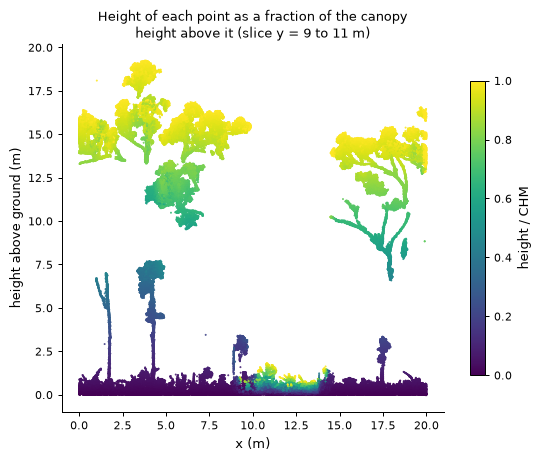

In [7]:
dtm = ground.make_dtm(cloud, 0.5, bounds=(0, 0, 20, 20))
chm = ground.make_chm(cloud, 0.5, bounds=(0, 0, 20, 20))
pts = interpolate.sample_rasters(cloud, {"ground": dtm, "canopy_height": chm})
h = pts.z - pts.attrs["ground"]
print("largest difference from normalize_height:", np.abs(h - cloud.attrs["height"]).max(), "m")
tall = (pts.attrs["canopy_height"] > 10) & (cloud.attrs["classification"] == 4)
relative = h / pts.attrs["canopy_height"]
print(f"vegetation under canopy taller than 10 m: {tall.sum():,} points, "
      f"{np.mean(relative[tall] < 1 / 3):.0%} of them in the lowest third of their column")

small = ground.make_dtm(cloud, 0.5, bounds=(5, 5, 15, 15))
outside = np.isnan(interpolate.sample_raster(cloud, small, "ground").attrs["ground"])
print(f"a DTM of the inner 10 x 10 m only: {outside.mean():.0%} of the points fall outside it and get NaN")

slab = (cloud.y > 9) & (cloud.y < 11)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(cloud.x[slab], h[slab], c=np.clip(relative[slab], 0, 1), s=0.3)
ax.set(title="Height of each point as a fraction of the canopy\nheight above it (slice y = 9 to 11 m)",
       xlabel="x (m)", ylabel="height above ground (m)", aspect="equal")
fig.colorbar(sc, ax=ax, shrink=0.8, label="height / CHM");